# Проект E-Commerce

Компания попросила провести анализ текущего состояния продаж для оценки успешности бизнеса.

#### Цели исследования:

- Разобраться в данных, предоставленных компанией
- Построить базовые метрики, изобразить их визуально
- Сделать выводы о текущем состоянии бизнеса

#### Ход Исследования:

- Предварительно в PostgreSQL обработал данные, построил основные метрики (общая выручка, количесвто заказов, средний чек, медианный чек)
- Выгружу таблицу с метриками в notebook для визуализации и подтверждения выводов, сделаных на предыдущем этапе

Во время обработки данных в SQL, сформировались следующие выводы:

- Текущее состяние бизнеса стабильное
- Выручка увеличилась на 1%
- Количество заказов на 3%
- Все это привело к падению среднего чека
- Медианный чек остался без изменений

#### Ограничения данных

Изначально данные содержали неполные периоды, что приводило к искажённой интерпретации. Для корректного анализа использовалось сравнение сопоставимых периодов (Jan–Sep).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('SQL.csv', sep=',')
df.head()

,date_year,date_month,total_revenue,orders_count,average_revenue,median_revenue
0,2024,1,229277.92,1386.0,165.42,61.460
1,2024,2,239790.26,1358.0,176.58,57.555
2,2024,3,259916.01,1423.0,182.65,59.260
3,2024,4,278733.29,1436.0,194.10,62.700
4,2024,5,279561.87,1427.0,195.91,63.020


Импортируем таблицу, затем смотрим с целью проверки данных во время перехода из SQL в notebook. Наблюдаем целостность датафрейма.

Text(0, 0.5, 'Выручка')

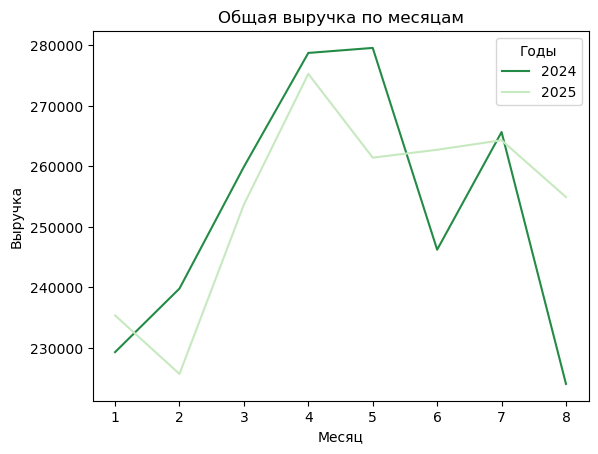

In [3]:
sns.lineplot(x=df['date_month'], y=df['total_revenue'], hue=df['date_year'], palette=['#238b45','#c7e9c0'])
plt.legend(title='Годы')
plt.title('Общая выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')

График отношения выручки по месяцам между отчетными годами. Наблюдаем, что большую часть времени выручка в 2024 году была чуть больше, чем в 2025, но в двух месяцах есть просадки.

Text(0, 0.5, 'Количество заказов')

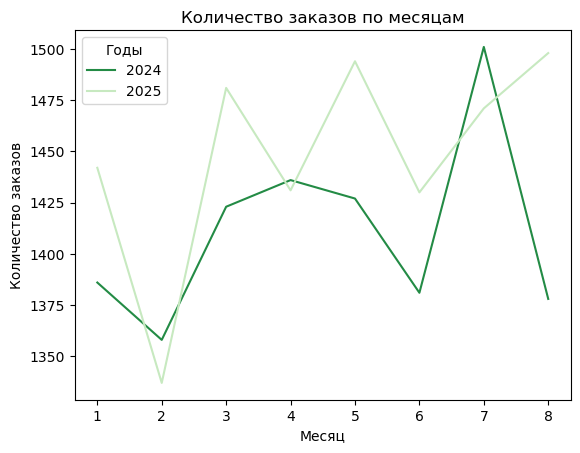

In [4]:
sns.lineplot(x=df['date_month'], y=df['orders_count'], hue=df['date_year'], palette=['#238b45','#c7e9c0'])
plt.legend(title='Годы')
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

График отношения количества заказов по месяцам между отчетными годами. Данные свидетельствуют о схожей тенденции продаж в оба периода, но в 2025 они более остро уходят вверх и вниз. Это говорит о том, что покупатели также более остро реагировали на сезонность продаж.

Text(0, 0.5, 'Средний чек')

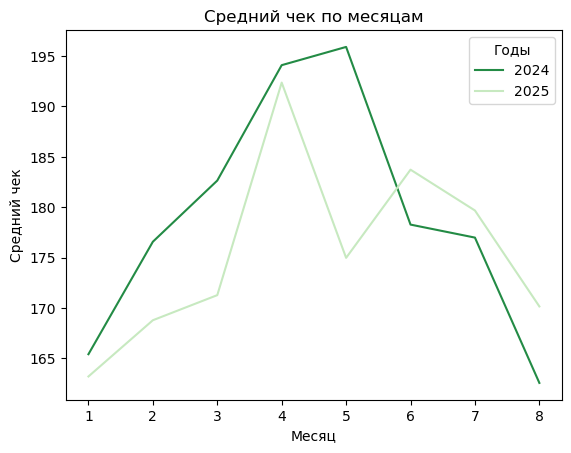

In [5]:
sns.lineplot(x=df['date_month'], y=df['average_revenue'], hue=df['date_year'], palette=['#238b45','#c7e9c0'])
plt.legend(title='Годы')
plt.title('Средний чек по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний чек')

График отношения среднего чека по месяцам между отчетными годами. Данные подтверждают вывод, что средний чек за 2025 год упал. Большую часть времени он находится ниже, чем за 2024 год. Это может указывать на смещение структуры покупок в сторону менее дорогих товаров.

Text(0, 0.5, 'Выручка')

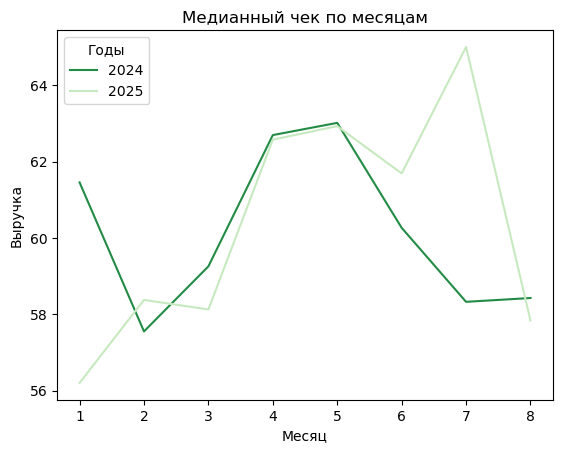

In [6]:
sns.lineplot(x=df['date_month'], y=df['median_revenue'], hue=df['date_year'], palette=['#238b45','#c7e9c0'])
plt.legend(title='Годы')
plt.title('Медианный чек по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')

График отношения медианного чека по месяцам между отчетными годами. Согласно выводам, медианный чек остался без изменений. График свидетельствует, что в некоторые моменты медианные чеки за отчетные периоды прямо повторяют друг друга, но в двух моментах сильно различаются. Эти расхождения в итоге компенсируются и итоговые медианные чеки за весь период не отличаются.

## Вывод:

Первичный анализ показал снижение ключевых метрик, однако было выявлено, что данные за текущий период неполные (Jan–Sep), поэтому дальнейшее сравнение проводилось только по сопоставимым периодам.

В результате установлено, что выручка выросла примерно на 1%, тогда как количество заказов увеличилось на ~3%. Это указывает на снижение среднего чека.

При этом медианный чек остался на прежнем уровне, что свидетельствует о сокращении доли крупных заказов при неизменном поведении основной массы пользователей.

Таким образом, текущая динамика бизнеса характеризуется стабильным спросом при изменении структуры покупок в сторону менее дорогих заказов.